# 📊 Data Panel — Reportes Financieros Trimestrales
### Mariann Antonelli Morales Tobias | A01452078
**Econometría Financiera — Proyecto Final**

Notebook **100% configurable**. Al correrlo te pedirá:
1. Subir tus archivos Excel (Balance, Estado de Resultados, Flujo de Efectivo) de cada empresa.
2. Indicar cuántas empresas tienes y sus tickers.
3. Elegir tu variable dependiente e independientes.

Genera automáticamente:
- Tabla de ratios financieros por empresa y trimestre.
- Estadísticas descriptivas del panel.
- Gráficas comparativas.
- Modelos: Pooled OLS, Efectos Fijos, Efectos Aleatorios.
- Prueba de Hausman.
- **PDF con resumen completo de resultados**.

In [1]:
# ============================================================
# CELDA 1 — INSTALACIÓN
# ============================================================
!pip install linearmodels openpyxl reportlab -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.backends.backend_pdf as pdf_backend
import seaborn as sns
import warnings
import statsmodels.api as sm
from linearmodels import PanelOLS, PooledOLS, RandomEffects
from linearmodels.panel import compare
from scipy import stats
from google.colab import files
warnings.filterwarnings('ignore')
print('✅ Librerías listas')

✅ Librerías listas


## 1. 📂 Carga de archivos

In [2]:
# ============================================================
# CELDA 2 — CONFIGURACIÓN INTERACTIVA
# ============================================================
print('=' * 60)
print('  CONFIGURACIÓN DEL MODELO DE DATA PANEL')
print('=' * 60)

# Número de empresas
n_empresas = int(input('\n¿Cuántas empresas vas a analizar? (ej: 6): ').strip())

# Tickers
TICKERS = []
for i in range(n_empresas):
    t = input(f'  Ticker empresa {i+1} (ej: CMI): ').strip().upper()
    TICKERS.append(t)

print(f'\n✅ Empresas configuradas: {TICKERS}')

# Qué estados tiene cada empresa
print('\n¿Qué archivos tienes para cada empresa?')
print('  IS  = Estado de Resultados')
print('  BS  = Balance General')
print('  CF  = Flujo de Efectivo')
estados_input = input('Ingresa los que tienes separados por coma (ej: IS,BS,CF): ').strip().upper()
ESTADOS = [e.strip() for e in estados_input.split(',')]
print(f'✅ Estados a cargar: {ESTADOS}')

  CONFIGURACIÓN DEL MODELO DE DATA PANEL

¿Cuántas empresas vas a analizar? (ej: 6): 6
  Ticker empresa 1 (ej: CMI): CMI
  Ticker empresa 2 (ej: CMI): CAT
  Ticker empresa 3 (ej: CMI): DE
  Ticker empresa 4 (ej: CMI): PCAR
  Ticker empresa 5 (ej: CMI): NUE
  Ticker empresa 6 (ej: CMI): PH

✅ Empresas configuradas: ['CMI', 'CAT', 'DE', 'PCAR', 'NUE', 'PH']

¿Qué archivos tienes para cada empresa?
  IS  = Estado de Resultados
  BS  = Balance General
  CF  = Flujo de Efectivo
Ingresa los que tienes separados por coma (ej: IS,BS,CF): IS,BS,CF
✅ Estados a cargar: ['IS', 'BS', 'CF']


In [3]:
# ============================================================
# CELDA 3 — CARGA DE ARCHIVOS (uno por uno)
# ============================================================
# Función lectora: entiende el formato Bloomberg con
# fila 3 = etiquetas de período, fila 4 = fechas,
# col 0 = nombre variable, col 1 = ticker Bloomberg

def leer_bloomberg(ruta_o_bytes, empresa, estado):
    """
    Lee un Excel Bloomberg (formato wide) y devuelve DataFrame long.
    Funciona si le pasas ruta de archivo o bytes desde files.upload().
    """
    import io
    if isinstance(ruta_o_bytes, (str,)):
        df_raw = pd.read_excel(ruta_o_bytes, header=None)
    else:
        df_raw = pd.read_excel(io.BytesIO(ruta_o_bytes), header=None)

    # Fila 4 (índice 4) contiene las fechas desde columna 2
    fechas_raw = df_raw.iloc[4, 2:].tolist()
    fechas = []
    for f in fechas_raw:
        if pd.notna(f):
            try:
                fechas.append(pd.to_datetime(str(f)[:10]))
            except:
                pass

    n_fechas = len(fechas)
    if n_fechas == 0:
        print(f'  ⚠️  No se detectaron fechas en {empresa}_{estado}')
        return pd.DataFrame()

    # Desde fila 5 en adelante: datos
    datos = df_raw.iloc[5:, :].copy()
    datos.columns = range(len(datos.columns))

    registros = []
    for _, row in datos.iterrows():
        nombre_var = str(row[0]).strip() if pd.notna(row[0]) else ''
        ticker_bbg = str(row[1]).strip() if pd.notna(row[1]) else ''

        # Solo filas con ticker Bloomberg válido (letras y guiones bajos)
        if not ticker_bbg or not ticker_bbg.replace('_','').isalpha():
            continue
        if len(ticker_bbg) < 3:
            continue

        vals = row[2:2+n_fechas].tolist()
        for fecha, val in zip(fechas, vals):
            registros.append({
                'empresa':    empresa,
                'estado':     estado,
                'variable':   nombre_var,
                'ticker_bbg': ticker_bbg,
                'fecha':      fecha,
                'valor':      pd.to_numeric(val, errors='coerce')
            })

    df_long = pd.DataFrame(registros)
    print(f'  ✅ {empresa}_{estado}: {n_fechas} trimestres, {df_long["ticker_bbg"].nunique()} variables')
    return df_long


# ── Subida de archivos ──────────────────────────────────────
print('=' * 60)
print('CARGA DE ARCHIVOS')
print('Sube TODOS tus archivos Excel de una vez.')
print(f'Necesitas {len(TICKERS) * len(ESTADOS)} archivos en total.')
print('Nombrarlos como: CMI_IS.xlsx, CMI_BS.xlsx, CMI_CF.xlsx, etc.')
print('=' * 60)

uploaded = files.upload()   # sube todos de golpe

# Procesar cada archivo subido
dfs = []
archivos_procesados = []

for nombre_archivo, contenido in uploaded.items():
    # Detectar empresa y estado desde el nombre del archivo
    nombre_limpio = nombre_archivo.replace('.xlsx','').replace('.xls','').upper()
    partes = nombre_limpio.split('_')

    if len(partes) < 2:
        print(f'  ⚠️  No se pudo interpretar: {nombre_archivo} (formato esperado: TICKER_ESTADO.xlsx)')
        continue

    empresa = partes[0]
    estado  = partes[1]

    if empresa not in TICKERS:
        print(f'  ⚠️  {empresa} no está en tu lista de tickers configurados')
        continue

    df_temp = leer_bloomberg(contenido, empresa, estado)
    if not df_temp.empty:
        dfs.append(df_temp)
        archivos_procesados.append(f'{empresa}_{estado}')

if dfs:
    df_all = pd.concat(dfs, ignore_index=True)
    print(f'\n✅ Total: {len(archivos_procesados)} archivos procesados')
    print(f'   Registros totales: {len(df_all):,}')
    print(f'   Empresas: {df_all["empresa"].unique()}')
    print(f'   Rango: {df_all["fecha"].min().date()} → {df_all["fecha"].max().date()}')
else:
    print('❌ No se procesó ningún archivo. Verifica los nombres.')

CARGA DE ARCHIVOS
Sube TODOS tus archivos Excel de una vez.
Necesitas 18 archivos en total.
Nombrarlos como: CMI_IS.xlsx, CMI_BS.xlsx, CMI_CF.xlsx, etc.


Saving CAT_BS.xlsx to CAT_BS (3).xlsx
Saving CAT_CF.xlsx to CAT_CF (3).xlsx
Saving CAT_IS.xlsx to CAT_IS (3).xlsx
Saving CMI_BS.xlsx to CMI_BS (3).xlsx
Saving CMI_CF.xlsx to CMI_CF (3).xlsx
Saving CMI_IS.xlsx to CMI_IS (3).xlsx
Saving DE_BS.xlsx to DE_BS (3).xlsx
Saving DE_CF.xlsx to DE_CF (3).xlsx
Saving DE_IS.xlsx to DE_IS (3).xlsx
Saving NUE_BS.xlsx to NUE_BS (3).xlsx
Saving NUE_CF.xlsx to NUE_CF (3).xlsx
Saving NUE_IS.xlsx to NUE_IS (3).xlsx
Saving PCAR_BS.xlsx to PCAR_BS (3).xlsx
Saving PCAR_CF.xlsx to PCAR_CF (3).xlsx
Saving PCAR_IS.xlsx to PCAR_IS (3).xlsx
Saving PH_BS.xlsx to PH_BS (3).xlsx
Saving PH_CF.xlsx to PH_CF (3).xlsx
Saving PH_IS.xlsx to PH_IS (3).xlsx
  ✅ CAT_BS (3): 30 trimestres, 83 variables
  ✅ CAT_CF (3): 30 trimestres, 51 variables
  ✅ CAT_IS (3): 30 trimestres, 62 variables
  ✅ CMI_BS (3): 30 trimestres, 81 variables
  ✅ CMI_CF (3): 30 trimestres, 52 variables
  ✅ CMI_IS (3): 30 trimestres, 60 variables
  ✅ DE_BS (3): 30 trimestres, 88 variables
  ✅ DE_CF (3): 

## 2. 🔢 Construcción del Panel

In [4]:
# ============================================================
# CELDA 4 — PIVOTEAR A FORMATO WIDE (empresa x fecha)
# ============================================================

# Una fila por (empresa, fecha), columnas = ticker_bbg
df_pivot = df_all.pivot_table(
    index=['empresa', 'fecha'],
    columns='ticker_bbg',
    values='valor',
    aggfunc='first'
).reset_index()
df_pivot.columns.name = None

print(f'Dimensiones del panel: {df_pivot.shape[0]} observaciones x {df_pivot.shape[1]-2} variables')
print(f'Empresas: {df_pivot["empresa"].unique()}')
print(f'Trimestres por empresa:')
print(df_pivot.groupby('empresa')['fecha'].count())
df_pivot.head()

Dimensiones del panel: 192 observaciones x 216 variables
Empresas: ['CAT' 'CMI' 'DE' 'NUE' 'PCAR' 'PH']
Trimestres por empresa:
empresa
CAT     32
CMI     32
DE      32
NUE     32
PCAR    32
PH      32
Name: fecha, dtype: int64


,empresa,fecha,ACCT_PAYABLE_ACCRUALS_DETAILED,ACQUIS_OF_FIXED_INTANG,ACTUAL_SALES_PER_EMPL,BS_ACCRUAL,BS_ACCRUED_LIABILITIES,BS_ACCTS_REC_EXCL_NOTES_REC,BS_ACCT_NOTE_RCV,BS_ACCT_PAYABLE,...,PX_TO_FREE_CASH_FLOW,SALES_REV_TURN,SHORT_TERM_DEBT_DETAILED,ST_CAPITALIZED_LEASE_LIABILITIES,ST_CAPITAL_LEASE_OBLIGATIONS,ST_DEFERRED_REVENUE,TCE_RATIO,TOTAL_EQUITY,TOT_LIAB_AND_EQY,XO_GL_NET_OF_TAX
0,CAT,2018-09-30,12221.0,-601.0,NaN,5433.0,NaN,7949.0,16773.0,6788.0,...,41.4568,NaN,4521.0,NaN,NaN,NaN,10.9157,15890.0,78209.0,NaN
1,CAT,2018-12-31,13362.0,-787.0,NaN,5816.0,0.0,8714.0,17364.0,7051.0,...,20.5871,NaN,5723.0,NaN,NaN,0.0,8.4168,14080.0,78509.0,NaN
2,CAT,2019-03-31,12041.0,-547.0,129480.7692,4843.0,NaN,8890.0,17822.0,7198.0,...,19.7006,13466.0,5590.0,188.0,NaN,NaN,10.5178,15478.0,78726.0,0.0
3,CAT,2019-06-30,12681.0,-678.0,NaN,5080.0,NaN,8910.0,18449.0,7022.0,...,17.1830,14432.0,5266.0,187.0,NaN,NaN,9.6753,14878.0,79187.0,0.0
4,CAT,2019-09-30,11266.0,-631.0,NaN,5125.0,0.0,8182.0,17374.0,6141.0,...,18.4561,12758.0,4268.0,178.0,NaN,0.0,10.2249,14993.0,77993.0,0.0


In [5]:
# ============================================================
# CELDA 5 — CÁLCULO DE RATIOS (corregido con tus columnas)
# ============================================================

panel = df_pivot.copy()
ratios_ok = []

def safe_ratio(num_col, den_col, nombre):
    if num_col in panel.columns and den_col in panel.columns:
        panel[nombre] = panel[num_col] / panel[den_col].replace(0, np.nan)
        ratios_ok.append(nombre)
        print(f'  ✅ {nombre}')
    else:
        miss = [c for c in [num_col, den_col] if c not in panel.columns]
        print(f'  ⚠️  {nombre}: falta {miss}')

print('Calculando ratios...\n')

# Rentabilidad
safe_ratio('NET_INCOME',     'TOTAL_EQUITY',      'ROE')
safe_ratio('NET_INCOME',     'BS_TOT_ASSET',      'ROA')
safe_ratio('GROSS_PROFIT',   'SALES_REV_TURN',    'margen_bruto')
safe_ratio('IS_OPER_INC',    'SALES_REV_TURN',    'margen_operativo')
safe_ratio('NET_INCOME',     'SALES_REV_TURN',    'margen_neto')
safe_ratio('EBITDA',         'SALES_REV_TURN',    'margen_ebitda')

# Liquidez
safe_ratio('BS_CUR_ASSET_REPORT', 'BS_CUR_LIAB',  'razon_corriente')

# Endeudamiento
safe_ratio('NON_CUR_LIAB',   'BS_TOT_ASSET',      'apalancamiento')
safe_ratio('BS_LT_BORROW',   'TOTAL_EQUITY',      'deuda_capital')
safe_ratio('NET_DEBT',       'TOTAL_EQUITY',      'deuda_neta_capital')

# Crecimiento
if 'SALES_REV_TURN' in panel.columns:
    panel = panel.sort_values(['empresa','fecha'])
    panel['crecimiento_ventas'] = (
        panel.groupby('empresa')['SALES_REV_TURN'].pct_change(4)
    )
    ratios_ok.append('crecimiento_ventas')
    print('  ✅ crecimiento_ventas')

# Free Cash Flow
safe_ratio('CF_FREE_CASH_FLOW', 'SALES_REV_TURN', 'fcf_ventas')

print(f'\n📋 Ratios calculados: {ratios_ok}')

Calculando ratios...

  ✅ ROE
  ✅ ROA
  ✅ margen_bruto
  ✅ margen_operativo
  ✅ margen_neto
  ✅ margen_ebitda
  ✅ razon_corriente
  ✅ apalancamiento
  ✅ deuda_capital
  ✅ deuda_neta_capital
  ✅ crecimiento_ventas
  ✅ fcf_ventas

📋 Ratios calculados: ['ROE', 'ROA', 'margen_bruto', 'margen_operativo', 'margen_neto', 'margen_ebitda', 'razon_corriente', 'apalancamiento', 'deuda_capital', 'deuda_neta_capital', 'crecimiento_ventas', 'fcf_ventas']


In [6]:
# ============================================================
# CELDA 6 — SELECCIÓN INTERACTIVA DE VARIABLES DEL MODELO
# ============================================================

print('=' * 60)
print('VARIABLES DISPONIBLES PARA EL MODELO')
print('=' * 60)
for i, r in enumerate(ratios_ok):
    print(f'  {i+1:2d}. {r}')

print()
VAR_DEP = input('Variable DEPENDIENTE (escribe el nombre exacto, ej: ROE): ').strip()

print(f'\nVariables INDEPENDIENTES (sin incluir {VAR_DEP})')
print('Escríbelas separadas por coma (ej: ROA,apalancamiento,crecimiento_ventas)')
vars_ind_input = input('Variables independientes: ').strip()
VARS_IND = [v.strip() for v in vars_ind_input.split(',')]

# Validar que existan
vars_validas  = [v for v in VARS_IND if v in ratios_ok]
vars_invalidas = [v for v in VARS_IND if v not in ratios_ok]

if vars_invalidas:
    print(f'\n⚠️  No encontradas (se ignorarán): {vars_invalidas}')
VARS_IND = vars_validas

print(f'\n✅ Modelo configurado:')
print(f'   Dependiente : {VAR_DEP}')
print(f'   Independientes: {VARS_IND}')

VARIABLES DISPONIBLES PARA EL MODELO
   1. ROE
   2. ROA
   3. margen_bruto
   4. margen_operativo
   5. margen_neto
   6. margen_ebitda
   7. razon_corriente
   8. apalancamiento
   9. deuda_capital
  10. deuda_neta_capital
  11. crecimiento_ventas
  12. fcf_ventas

Variable DEPENDIENTE (escribe el nombre exacto, ej: ROE): ROE

Variables INDEPENDIENTES (sin incluir ROE)
Escríbelas separadas por coma (ej: ROA,apalancamiento,crecimiento_ventas)
Variables independientes: margen_operativo, apalancamiento, crecimiento_ventas, razon_corriente

✅ Modelo configurado:
   Dependiente : ROE
   Independientes: ['margen_operativo', 'apalancamiento', 'crecimiento_ventas', 'razon_corriente']


## 3. 📈 Estadísticas Descriptivas y Gráficas

In [7]:
# ============================================================
# CELDA 7 — ESTADÍSTICAS DESCRIPTIVAS
# ============================================================

vars_modelo = [VAR_DEP] + VARS_IND
vars_modelo = [v for v in vars_modelo if v in panel.columns]

print('=== ESTADÍSTICAS DESCRIPTIVAS GENERALES ===\n')
desc = panel[vars_modelo].describe().round(4)
print(desc.to_string())

print('\n=== PROMEDIO POR EMPRESA ===\n')
por_empresa = panel.groupby('empresa')[vars_modelo].mean().round(4)
print(por_empresa.to_string())

=== ESTADÍSTICAS DESCRIPTIVAS GENERALES ===

            ROE  margen_operativo  apalancamiento  crecimiento_ventas  razon_corriente
count  168.0000          180.0000        180.0000            156.0000         180.0000
mean     0.0673            0.1538          0.3639              0.0639           1.5781
std      0.0391            0.0590          0.0854              0.2307           0.8300
min     -0.1445           -0.1419          0.2205             -0.5380           0.6557
25%      0.0441            0.1153          0.2890             -0.0785           1.0653
50%      0.0628            0.1497          0.3568              0.0316           1.3840
75%      0.0841            0.1924          0.4336              0.1664           1.6669
max      0.1973            0.3349          0.5278              1.0928           4.3943

=== PROMEDIO POR EMPRESA ===

            ROE  margen_operativo  apalancamiento  crecimiento_ventas  razon_corriente
empresa                                               

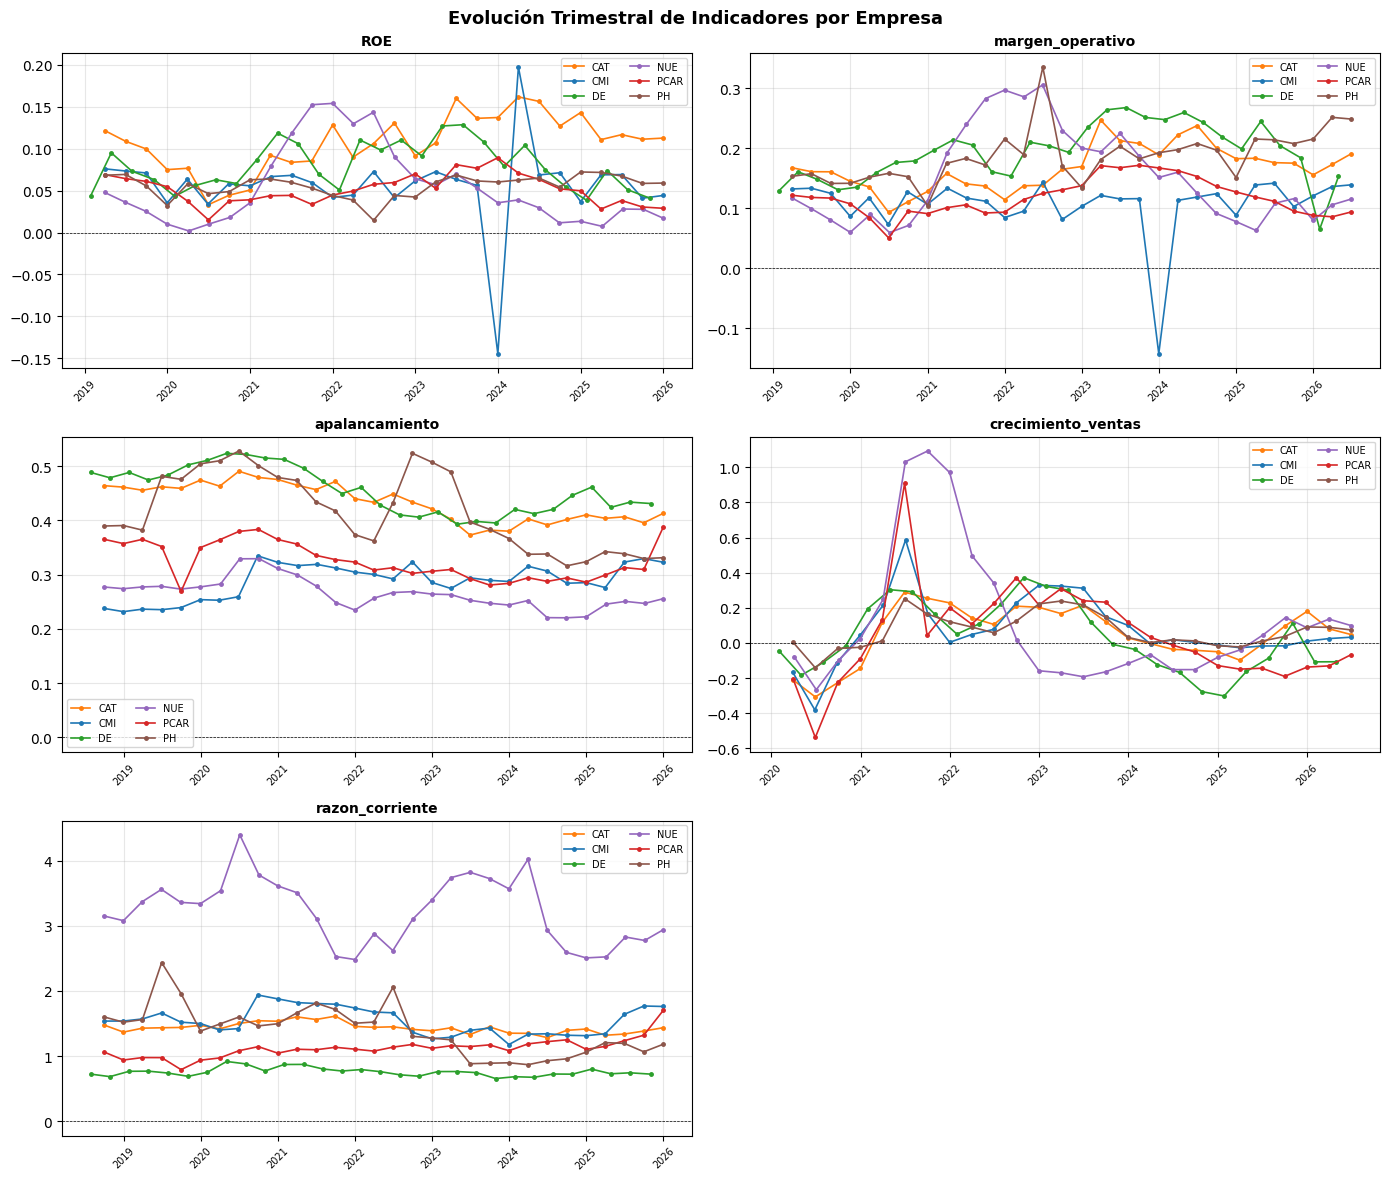

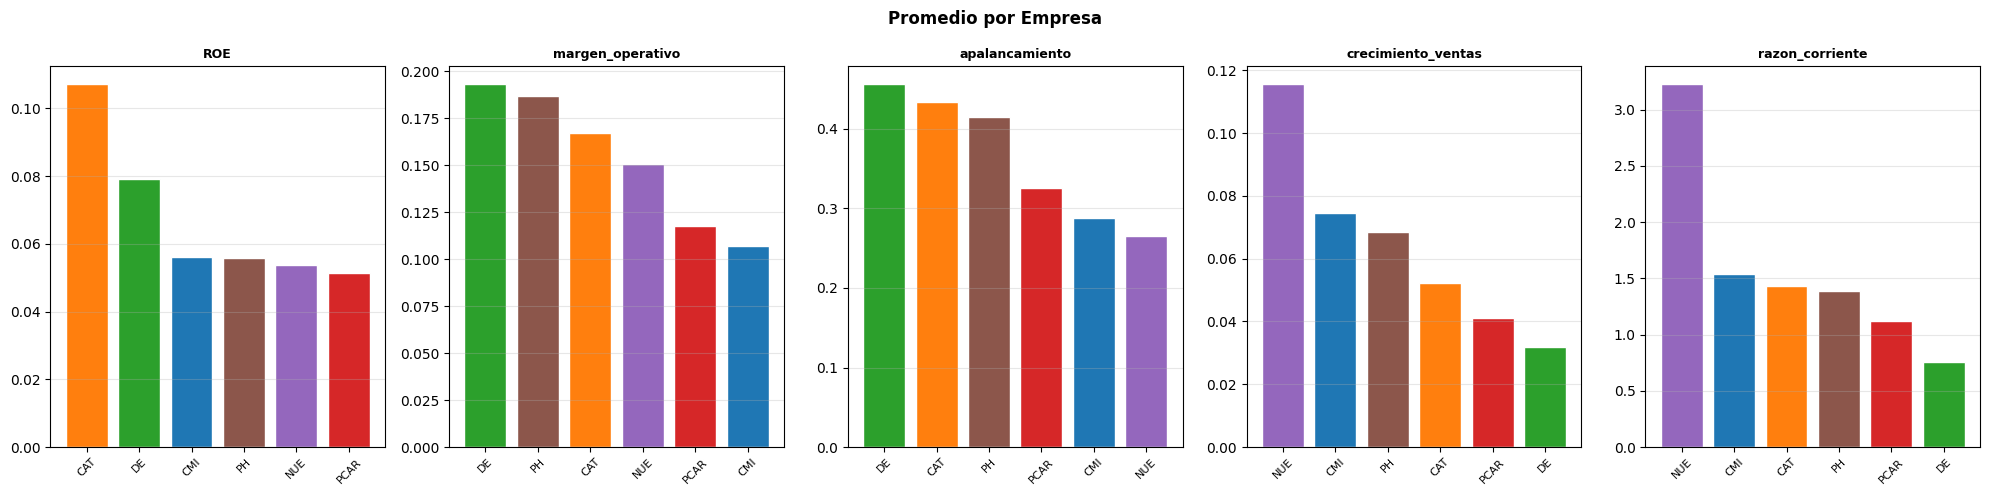

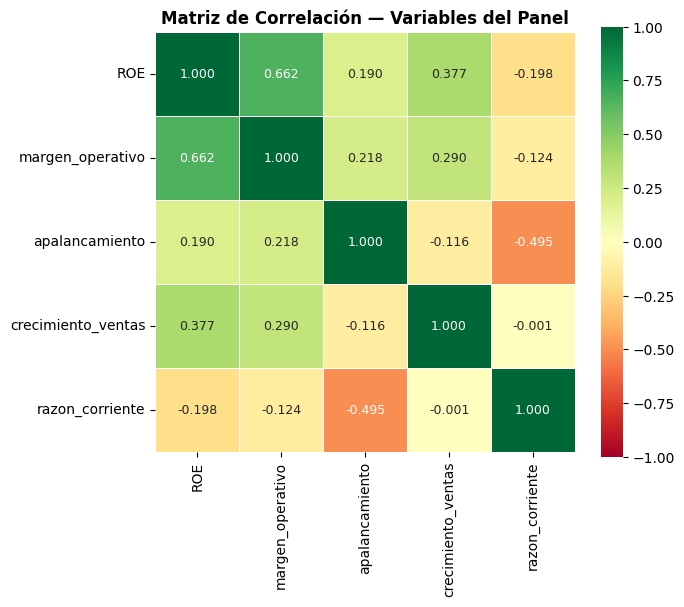

✅ 3 gráficas generadas


In [8]:
# ============================================================
# CELDA 8 — GRÁFICAS COMPARATIVAS (guardadas para el PDF)
# ============================================================

GRAFICAS_PATHS = []   # lista donde guardamos todas las figuras

colores_base = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd',
                '#8c564b','#e377c2','#7f7f7f','#bcbd22','#17becf']
color_map = {e: colores_base[i % len(colores_base)] for i, e in enumerate(TICKERS)}

# ── Gráfica 1: evolución temporal de todas las variables del modelo ──
n_vars = len(vars_modelo)
ncols = 2
nrows = (n_vars + 1) // 2

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
axes = np.array(axes).flatten()
fig.suptitle('Evolución Trimestral de Indicadores por Empresa', fontsize=13, fontweight='bold')

for idx, var in enumerate(vars_modelo):
    ax = axes[idx]
    for empresa in panel['empresa'].unique():
        sub = panel[panel['empresa'] == empresa].sort_values('fecha')
        ax.plot(sub['fecha'], sub[var], label=empresa,
                color=color_map.get(empresa,'gray'), marker='o', markersize=2.5, linewidth=1.2)
    ax.set_title(var, fontweight='bold', fontsize=10)
    ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
    ax.legend(fontsize=7, ncol=2)
    ax.grid(alpha=0.3)
    ax.tick_params(axis='x', rotation=45, labelsize=7)

for i in range(n_vars, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
ruta_g1 = '/content/grafica_evolucion.png'
plt.savefig(ruta_g1, dpi=130, bbox_inches='tight')
GRAFICAS_PATHS.append(ruta_g1)
plt.show()

# ── Gráfica 2: promedios por empresa (barras) ──
fig2, axes2 = plt.subplots(1, len(vars_modelo), figsize=(4 * len(vars_modelo), 5))
if len(vars_modelo) == 1:
    axes2 = [axes2]
fig2.suptitle('Promedio por Empresa', fontsize=12, fontweight='bold')

for idx, var in enumerate(vars_modelo):
    medias = panel.groupby('empresa')[var].mean().sort_values(ascending=False)
    colores_bar = [color_map.get(e,'gray') for e in medias.index]
    axes2[idx].bar(medias.index, medias.values, color=colores_bar, edgecolor='white')
    axes2[idx].set_title(var, fontweight='bold', fontsize=9)
    axes2[idx].axhline(0, color='black', linewidth=0.5)
    axes2[idx].tick_params(axis='x', rotation=45, labelsize=8)
    axes2[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
ruta_g2 = '/content/grafica_promedios.png'
plt.savefig(ruta_g2, dpi=130, bbox_inches='tight')
GRAFICAS_PATHS.append(ruta_g2)
plt.show()

# ── Gráfica 3: matriz de correlación ──
fig3, ax3 = plt.subplots(figsize=(max(7, n_vars), max(6, n_vars - 1)))
corr = panel[vars_modelo].corr()
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdYlGn', center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax3, annot_kws={'size': 9})
ax3.set_title('Matriz de Correlación — Variables del Panel', fontweight='bold')
plt.tight_layout()
ruta_g3 = '/content/grafica_correlacion.png'
plt.savefig(ruta_g3, dpi=130, bbox_inches='tight')
GRAFICAS_PATHS.append(ruta_g3)
plt.show()

print(f'✅ {len(GRAFICAS_PATHS)} gráficas generadas')

## 4. 🧮 Modelos de Data Panel

In [9]:
# ============================================================
# CELDA 9 — PREPARAR DATOS Y CORRER LOS 4 MODELOS
# ============================================================

# Preparar DataFrame con solo las variables del modelo, sin NaN
df_modelo = panel[['empresa','fecha'] + vars_modelo].dropna()
df_modelo = df_modelo.set_index(['empresa','fecha'])

print(f'Observaciones en el modelo: {len(df_modelo)}')
print(f'Empresas: {df_modelo.index.get_level_values(0).nunique()}')
print(f'Periodos: {df_modelo.index.get_level_values(1).nunique()}\n')

y = df_modelo[VAR_DEP]
X = sm.add_constant(df_modelo[VARS_IND])

RESULTADOS = {}

# ── Modelo 1: Pooled OLS ──────────────────────────────────
try:
    res_pool = PooledOLS(y, X).fit(cov_type='robust')
    RESULTADOS['Pooled OLS'] = res_pool
    print('✅ Pooled OLS estimado')
except Exception as e:
    print(f'❌ Pooled OLS: {e}')

# ── Modelo 2: Efectos Fijos (empresa) ────────────────────
try:
    res_fe = PanelOLS(y, X, entity_effects=True, time_effects=False).fit(cov_type='robust')
    RESULTADOS['Efectos Fijos'] = res_fe
    print('✅ Efectos Fijos estimado')
except Exception as e:
    print(f'❌ Efectos Fijos: {e}')

# ── Modelo 3: Efectos Fijos Dobles ───────────────────────
try:
    res_fe2 = PanelOLS(y, X, entity_effects=True, time_effects=True).fit(cov_type='robust')
    RESULTADOS['EF Dobles'] = res_fe2
    print('✅ Efectos Fijos Dobles estimado')
except Exception as e:
    print(f'❌ Efectos Fijos Dobles: {e}')

# ── Modelo 4: Efectos Aleatorios ─────────────────────────
try:
    res_re = RandomEffects(y, X).fit(cov_type='robust')
    RESULTADOS['Efectos Aleatorios'] = res_re
    print('✅ Efectos Aleatorios estimado')
except Exception as e:
    print(f'❌ Efectos Aleatorios: {e}')

# ── Comparación ──────────────────────────────────────────
print('\n=== COMPARACIÓN DE MODELOS ===')
try:
    comp = compare(RESULTADOS)
    print(comp)
except Exception as e:
    print(f'No se pudo comparar: {e}')
    for nombre, res in RESULTADOS.items():
        print(f'\n--- {nombre} ---')
        print(res.summary)

Observaciones en el modelo: 144
Empresas: 6
Periodos: 71

✅ Pooled OLS estimado
✅ Efectos Fijos estimado
✅ Efectos Fijos Dobles estimado
✅ Efectos Aleatorios estimado

=== COMPARACIÓN DE MODELOS ===
                                  Model Comparison                                  
                           Pooled OLS Efectos Fijos     EF Dobles Efectos Aleatorios
------------------------------------------------------------------------------------
Dep. Variable                     ROE           ROE           ROE                ROE
Estimator                   PooledOLS      PanelOLS      PanelOLS      RandomEffects
No. Observations                  144           144           144                144
Cov. Est.                      Robust        Robust        Robust             Robust
R-squared                      0.4884        0.6282        0.4677             0.6090
R-Squared (Within)             0.6034        0.6282        0.6155             0.6249
R-Squared (Between)            0.153

In [10]:
# ============================================================
# CELDA 10 — PRUEBA DE HAUSMAN
# ============================================================

HAUSMAN_RESULT = {}

if 'Efectos Fijos' in RESULTADOS and 'Efectos Aleatorios' in RESULTADOS:
    res_fe  = RESULTADOS['Efectos Fijos']
    res_re  = RESULTADOS['Efectos Aleatorios']

    b_fe = res_fe.params
    b_re = res_re.params
    common = b_fe.index.intersection(b_re.index)

    diff  = b_fe[common] - b_re[common]
    V_diff = res_fe.cov.loc[common, common] - res_re.cov.loc[common, common]

    try:
        H  = float(diff @ np.linalg.pinv(V_diff.values) @ diff)
        gl = len(common)
        pval = 1 - stats.chi2.cdf(H, gl)
        conclusion = 'EFECTOS FIJOS (p < 0.05)' if pval < 0.05 else 'EFECTOS ALEATORIOS (p >= 0.05)'

        HAUSMAN_RESULT = {'H': H, 'gl': gl, 'pval': pval, 'conclusion': conclusion}

        print('=' * 50)
        print('PRUEBA DE HAUSMAN')
        print('=' * 50)
        print(f'  H estadístico    : {H:.4f}')
        print(f'  Grados de libertad: {gl}')
        print(f'  p-value          : {pval:.4f}')
        print(f'  → Usar: {conclusion}')
    except Exception as e:
        print(f'⚠️  Hausman no calculable: {e}')
        HAUSMAN_RESULT = {'H': None, 'pval': None, 'conclusion': 'No calculable'}
else:
    print('⚠️  Se necesitan EF y EA para Hausman.')

PRUEBA DE HAUSMAN
  H estadístico    : 2.1860
  Grados de libertad: 5
  p-value          : 0.8229
  → Usar: EFECTOS ALEATORIOS (p >= 0.05)


## 5. 📄 Exportar PDF con todos los resultados

In [11]:
# ============================================================
# CELDA 11 — GENERAR PDF (todas las páginas mismo tamaño)
# ============================================================

from matplotlib.backends.backend_pdf import PdfPages
from datetime import datetime

PDF_PATH = '/content/DataPanel_Resultados.pdf'
PAGE_W, PAGE_H = 14, 8.5  # tamaño fijo carta horizontal para todas las páginas

def nueva_figura():
    """Crea siempre una figura del mismo tamaño."""
    fig = plt.figure(figsize=(PAGE_W, PAGE_H))
    return fig

def tabla_en_figura(df_tabla, titulo, fontsize=8):
    fig = nueva_figura()
    ax = fig.add_subplot(111)
    ax.axis('off')
    ax.set_title(titulo, fontweight='bold', fontsize=12, pad=15)

    cols_str  = [str(c) for c in df_tabla.columns]
    filas_str = [[str(round(v,4)) if isinstance(v, float) else str(v)
                  for v in row] for row in df_tabla.values]

    n_cols = len(cols_str)
    tabla = ax.table(
        cellText=filas_str,
        colLabels=cols_str,
        cellLoc='center',
        loc='center'
    )
    tabla.auto_set_font_size(False)
    tabla.set_fontsize(fontsize)
    tabla.auto_set_column_width(col=list(range(n_cols)))
    tabla.scale(1, 1.6)  # altura de filas uniforme

    for j in range(n_cols):
        tabla[(0,j)].set_facecolor('#1a3a5c')
        tabla[(0,j)].set_text_props(color='white', fontweight='bold')
    for i in range(1, len(filas_str)+1):
        color = '#F7FAFD' if i % 2 == 0 else 'white'
        for j in range(n_cols):
            tabla[(i,j)].set_facecolor(color)

    plt.tight_layout(pad=1.5)
    return fig


with PdfPages(PDF_PATH) as pdf:

    # ── PORTADA ──────────────────────────────────────────────
    fig_port = nueva_figura()
    fig_port.patch.set_facecolor('#1a3a5c')
    ax_p = fig_port.add_axes([0,0,1,1])
    ax_p.axis('off')
    ax_p.set_facecolor('#1a3a5c')
    ax_p.text(0.5, 0.72, 'DATA PANEL', ha='center', fontsize=38,
              fontweight='bold', color='white', transform=ax_p.transAxes)
    ax_p.text(0.5, 0.60, 'Reportes Financieros Trimestrales', ha='center',
              fontsize=22, color='#BDD7EE', transform=ax_p.transAxes)
    ax_p.text(0.5, 0.50, f'Empresas: {" | ".join(TICKERS)}', ha='center',
              fontsize=14, color='#BDD7EE', transform=ax_p.transAxes)
    ax_p.text(0.5, 0.42, f'Variable dependiente: {VAR_DEP}', ha='center',
              fontsize=13, color='white', transform=ax_p.transAxes)
    ax_p.text(0.5, 0.35, f'Variables independientes: {", ".join(VARS_IND)}',
              ha='center', fontsize=11, color='#BDD7EE', transform=ax_p.transAxes)
    ax_p.text(0.5, 0.20, 'Mariann Antonelli Morales Tobias  |  A01452078',
              ha='center', fontsize=11, color='#BDD7EE', transform=ax_p.transAxes)
    ax_p.text(0.5, 0.14, f'Econometría Financiera — {datetime.today().strftime("%B %Y")}',
              ha='center', fontsize=10, color='#BDD7EE', transform=ax_p.transAxes)
    pdf.savefig(fig_port, bbox_inches='tight')
    plt.close(fig_port)

    # ── ESTADÍSTICAS DESCRIPTIVAS ─────────────────────────────
    desc_df = panel[vars_modelo].describe().round(4).reset_index()
    desc_df.rename(columns={'index':'Estadístico'}, inplace=True)
    fig_desc = tabla_en_figura(desc_df, 'Estadísticas Descriptivas — Panel Completo')
    pdf.savefig(fig_desc, bbox_inches='tight')
    plt.close(fig_desc)

    # ── PROMEDIO POR EMPRESA ──────────────────────────────────
    prom_df = panel.groupby('empresa')[vars_modelo].mean().round(4).reset_index()
    fig_prom = tabla_en_figura(prom_df, 'Promedio de Indicadores por Empresa')
    pdf.savefig(fig_prom, bbox_inches='tight')
    plt.close(fig_prom)

    # ── GRÁFICAS (reescaladas al tamaño fijo) ─────────────────
    for ruta_g in GRAFICAS_PATHS:
        try:
            img = plt.imread(ruta_g)
            fig_img = nueva_figura()
            ax_img = fig_img.add_axes([0.02, 0.02, 0.96, 0.96])
            ax_img.imshow(img)
            ax_img.axis('off')
            pdf.savefig(fig_img, bbox_inches='tight')
            plt.close(fig_img)
        except:
            pass

    # ── RESULTADOS DE CADA MODELO ─────────────────────────────
    for nombre_modelo, res in RESULTADOS.items():
        try:
            params_df = pd.DataFrame({
                'Variable':    res.params.index,
                'Coeficiente': res.params.values.round(6),
                'Std Error':   res.std_errors.values.round(6),
                't-stat':      res.tstats.values.round(4),
                'p-value':     res.pvalues.values.round(4),
                'Sig.': ['***' if p<0.001 else '**' if p<0.01
                         else '*' if p<0.05 else 'ns'
                         for p in res.pvalues.values]
            })
            try:    r2 = round(float(res.rsquared), 4)
            except: r2 = 'N/A'

            fig_m = tabla_en_figura(
                params_df,
                f'Modelo: {nombre_modelo}  |  Dep.: {VAR_DEP}  |  R² = {r2}'
            )
            pdf.savefig(fig_m, bbox_inches='tight')
            plt.close(fig_m)
        except Exception as e:
            print(f'⚠️  {nombre_modelo}: {e}')

    # ── HAUSMAN ───────────────────────────────────────────────
    if HAUSMAN_RESULT:
        fig_h = nueva_figura()
        ax_h  = fig_h.add_subplot(111)
        ax_h.axis('off')
        ax_h.set_title('Prueba de Hausman — Efectos Fijos vs. Aleatorios',
                       fontweight='bold', fontsize=12)
        H_val  = round(HAUSMAN_RESULT.get('H',0) or 0, 4)
        pval_h = round(HAUSMAN_RESULT.get('pval',0) or 0, 4)
        concl  = HAUSMAN_RESULT.get('conclusion','')
        gl_h   = HAUSMAN_RESULT.get('gl','')

        texto = [['H estadístico', str(H_val)],
                 ['Grados de libertad', str(gl_h)],
                 ['p-value', str(pval_h)],
                 ['Conclusión', concl]]
        t_h = ax_h.table(cellText=texto, colLabels=['Estadístico','Valor'],
                         cellLoc='center', loc='center')
        t_h.auto_set_font_size(False)
        t_h.set_fontsize(12)
        t_h.scale(1.5, 2.5)
        t_h[(0,0)].set_facecolor('#1a3a5c')
        t_h[(0,1)].set_facecolor('#1a3a5c')
        t_h[(0,0)].set_text_props(color='white', fontweight='bold')
        t_h[(0,1)].set_text_props(color='white', fontweight='bold')
        fill = '#D4EDDA' if 'FIJOS' in concl else '#FFF3CD'
        t_h[(4,0)].set_facecolor(fill)
        t_h[(4,1)].set_facecolor(fill)
        pdf.savefig(fig_h, bbox_inches='tight')
        plt.close(fig_h)

print(f'✅ PDF generado con páginas uniformes: {PDF_PATH}')


✅ PDF generado con páginas uniformes: /content/DataPanel_Resultados.pdf


In [12]:
# ============================================================
# CELDA 12 — DESCARGAR PDF
# ============================================================
from google.colab import files
files.download(PDF_PATH)
print(f'📥 Descargando {PDF_PATH}')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📥 Descargando /content/DataPanel_Resultados.pdf
